# 5. Party Share Bar Chart รายอำเภอ
สัดส่วนคะแนน บช (บัญชีรายชื่อ) แต่ละพรรครายอำเภอ — เห็นภาพว่าอำเภอไหนเป็นฐานพรรคไหน

In [1]:
import sys
!{sys.executable} -m pip install folium scikit-learn matplotlib seaborn -q

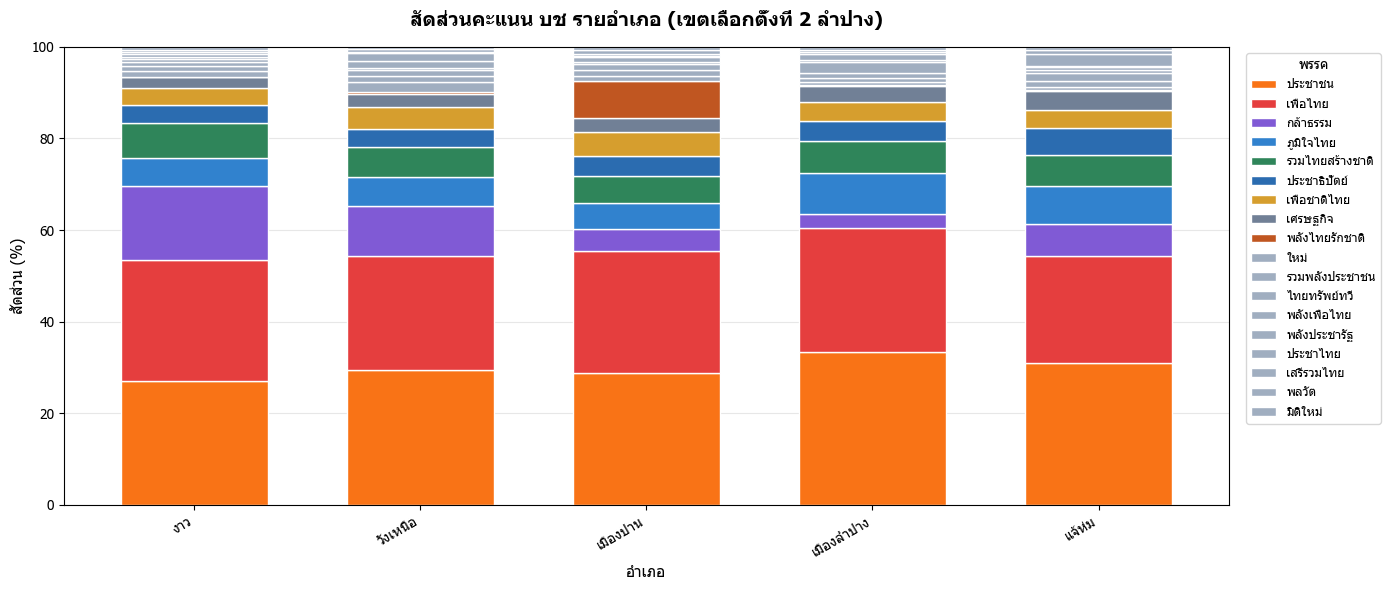


คะแนนรวม บช รายอำเภอ:
district
งาว           20017.0
แจ้ห่ม        18722.0
วังเหนือ      18505.0
เมืองปาน      15684.0
เมืองลำปาง     7685.0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Tahoma','DejaVu Sans']
from pathlib import Path

CLEAN = Path('../cleaned/')
results = pd.read_csv(CLEAN / 'master_results_cleaned.csv')

bch = results[(results['unit_number'] != -1) & (results['type'] == 'บช')]

# รวมคะแนน บช รายอำเภอรายพรรค
dist_party = bch.groupby(['district','name'])['score'].sum().reset_index()

# กรองเฉพาะพรรคที่มีคะแนนรวมทั้งเขต >= 500
top_parties = bch.groupby('name')['score'].sum()
top_parties = top_parties[top_parties >= 500].index.tolist()
dist_party = dist_party[dist_party['name'].isin(top_parties)]

# pivot
pivot = dist_party.pivot_table(index='district', columns='name', values='score', fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct[pivot_pct.sum().sort_values(ascending=False).index]

# สีพรรค
party_colors = {
    'ประชาชน':          '#F97316',
    'เพื่อไทย':         '#E53E3E',
    'กล้าธรรม':         '#805AD5',
    'ภูมิใจไทย':        '#3182CE',
    'รวมไทยสร้างชาติ':  '#2F855A',
    'ประชาธิปัตย์':     '#2B6CB0',
    'เพื่อชาติไทย':     '#D69E2E',
    'เศรษฐกิจ':         '#718096',
    'พลังไทยรักชาติ':   '#C05621',
}
colors = [party_colors.get(p, '#A0AEC0') for p in pivot_pct.columns]

fig, ax = plt.subplots(figsize=(14, 6))
pivot_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.65, edgecolor='white')

ax.set_title('สัดส่วนคะแนน บช รายอำเภอ (เขตเลือกตั้งที่ 2 ลำปาง)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('อำเภอ', fontsize=11)
ax.set_ylabel('สัดส่วน (%)', fontsize=11)
ax.set_xticklabels(pivot_pct.index, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 100)
ax.legend(title='พรรค', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print('\nคะแนนรวม บช รายอำเภอ:')
print(pivot.sum(axis=1).sort_values(ascending=False).to_string())
